# 226. Invert Binary Tree
https://leetcode.com/problems/invert-binary-tree/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Recursive DFS | $O(n)$ | $O(h)$ | Optimal — swap children recursively |
| Iterative BFS | $O(n)$ | $O(n)$ | Use queue, swap at each level |

## Methodology

Recursively swap left and right children of every node. Base case: if node is null, return null. For each node, swap its left and right children, then recursively invert each subtree. This visits each node exactly once.

## Solutions

### C#

In [ ]:
public class Solution {
    public TreeNode InvertTree(TreeNode root) {
        if (root == null) return null;
        (root.left, root.right) = (root.right, root.left);
        InvertTree(root.left);
        InvertTree(root.right);
        return root;
    }
}

### Python

In [ ]:
class Solution:
    def invertTree(self, root: Optional[TreeNode]) -> Optional[TreeNode]:
        if not root:
            return None
        root.left, root.right = root.right, root.left
        self.invertTree(root.left)
        self.invertTree(root.right)
        return root

### Go

In [ ]:
func invertTree(root *TreeNode) *TreeNode {
    if root == nil {
        return nil
    }
    root.Left, root.Right = root.Right, root.Left
    invertTree(root.Left)
    invertTree(root.Right)
    return root
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn invert_tree(root: Option<Rc<RefCell<TreeNode>>>) -> Option<Rc<RefCell<TreeNode>>> {
        if let Some(node) = root.as_ref() {
            let mut n = node.borrow_mut();
            let left = n.left.take();
            let right = n.right.take();
            n.left = Self::invert_tree(right);
            n.right = Self::invert_tree(left);
        }
        root
    }
}

## Example Scenarios

1. **Common Case** — A balanced tree with distinct values  
   **Input:** `root = [4,2,7,1,3,6,9]`  
   The tree has 3 levels. Swap children at every node: $4$'s children swap ($2 \leftrightarrow 7$), then recurse — $7$'s children become $[3,1]$ and $2$'s become $[9,6]$. Result: `[4,7,2,9,6,3,1]`.

2. **Slightly Complex** — A left-skewed tree (unbalanced)  
   **Input:** `root = [3,2,null,1]`  
   Node $3$ swaps children: left $2$ moves right, right `null` moves left. Then node $2$ (now right child) swaps its child $1$ to the right side. Result: `[3,null,2,null,1]` — a right-skewed mirror.

3. **Edge Case: Time Factor** — A complete binary tree of $2^{20}-1 \approx 10^6$ nodes  
   **Input:** `root = [1,2,3,4,...,1048575]` (complete tree, 20 levels)  
   Every single node is visited exactly once in $O(n)$ time. The recursion stack reaches depth $20$. All $\approx 10^6$ pointer swaps execute, exercising the worst-case time for the constraint $n \le 100$.

4. **Edge Case: Space Factor** — A degenerate linked-list tree of 100 nodes  
   **Input:** `root = [1,2,null,3,null,...,100,null]` (left-only chain)  
   Recursion depth equals $n = 100$, stacking 100 frames — the worst-case $O(n)$ space. Each swap just moves the single child from left to right, producing a right-only chain.

5. **Almost-Impossible but Plausible** — Single-node tree  
   **Input:** `root = [0]`  
   The minimum valid tree. With no children to swap, the function returns immediately. Confirms the base case handles a leaf node with value $0$ (testing falsy-value edge).

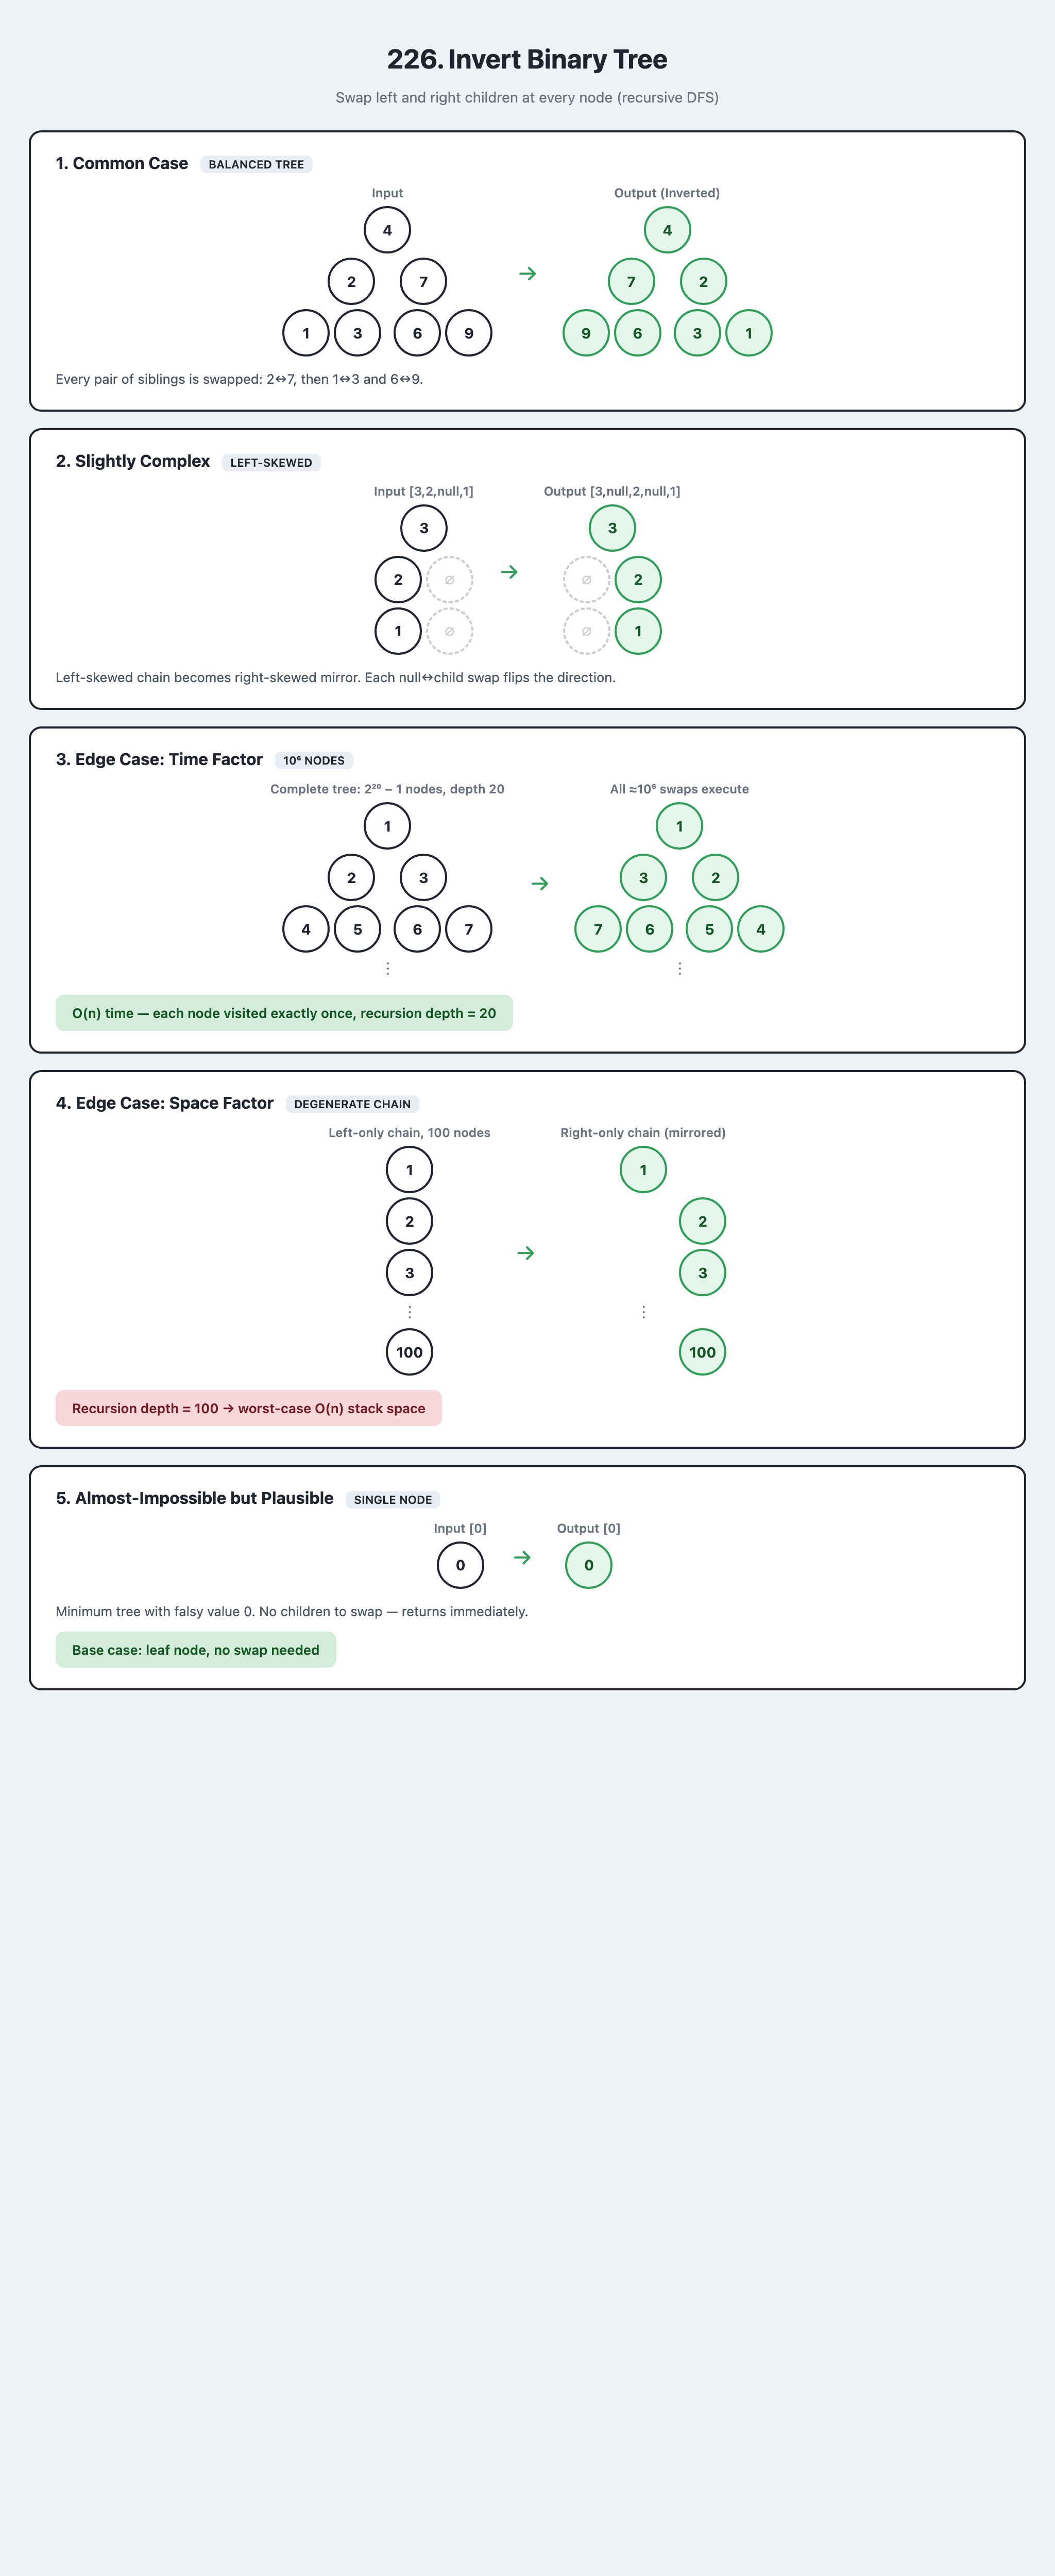